# M5A3 - Identificação de Elementos Visuais em UI de Aplicativos

> **Resumo:** Projeto de **detecção de objetos** aplicado a interfaces: refinamos um **Faster R-CNN** (backbone ResNet-50) para localizar componentes de UI (rectangle, text, group, image) em telas de apps móveis. Útil pra testes automatizados e acessibilidade. No fim, testamos o modelo fora-de-distribuição (o Sonic).

> ⚠️ **GPU recomendada** (Ambiente de execução → Alterar o tipo → GPU T4): treinar o Faster R-CNN em CPU é muito lento.

Na prática de hoje vamos refinar um modelo para a tarefa de identificação de elementos visuais em interfaces gráficas de aplicativos móveis.

Em projetos reais de desenvolvimento de software, a identificação automática de componentes de UI (como botões, ícones, campos de texto e contêineres) é crucial para automatizar testes funcionais (garantindo que o layout permaneça correto em diferentes dispositivos e modos claro/escuro) e para criar ferramentas de acessibilidade inteligentes para usuários portadores de deficiência visual.

Para essa tarefa, usaremos uma abordagem de **Detecção de Objetos** baseada em **Faster R-CNN** (com backbone ResNet-50). Em problemas de UI, também podem ser aplicados modelos de segmentação (como a UNet) para obter recortes precisos de botões, ou OCR (como Tesseract ou EasyOCR) para ler os rótulos internos das caixas detectadas.

Esse notebook está estruturado da seguinte forma.

- Introdução
- Carregar Base de Dados
- Refinar Modelo
- Validar o modelo
- Próximos passos
- Atividades Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
!pip install torch torchvision datasets tqdm ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 118.6 MB/s eta 0:00:00


Importar as bibliotecas

In [2]:
import datasets
import torch
import torchvision
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

## Carregar Base de Dados

A primeira tarefa para refinar um modelo é criar a base de dados.

Referência: https://huggingface.co/datasets/mrtoy/mobile-ui-design

In [3]:
# Baixando dataset.
# Esse dataset possui apenas split de treino.
dataset = datasets.load_dataset("mrtoy/mobile-ui-design", split="train")

# Split dataset.
split_ds = dataset.train_test_split(test_size=0.1, seed=42)

# Pegar splits de dados.
train_dataset = split_ds["train"]
test_dataset = split_ds["test"]

# Transformações dos dados.
def transforms(examples):
    # Transformações das imagens.
    transform_func = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(), # Transforma em tensor.
        torchvision.transforms.Resize((640, 480)), # Faz resize das imagens.
    ])

    images = []
    targets = []

    # Mapeamento de classes deslocado em +1 (pois o Faster R-CNN do PyTorch reserva a classe 0 para o background)
    label_map = {"rectangle": 1, "text": 2, "group": 3, "image": 4}

    target_h, target_w = 640, 480  # mesmo tamanho usado no Resize acima
    batch_size = len(examples["image"])
    for i in range(batch_size):
        img = examples["image"][i]
        # Tamanho original (PIL retorna largura, altura) ANTES do resize, para escalar as bboxes
        orig_w, orig_h = img.size
        sx, sy = target_w / orig_w, target_h / orig_h
        img_tensor = transform_func(img)
        # Garantir que imagens RGBA (4 canais) sejam convertidas para RGB (3 canais)
        if img_tensor.shape[0] == 4:
            img_tensor = img_tensor[:3, ...]
        images.append(img_tensor)

        objs = examples["objects"][i]
        len_objs = len(objs["category"])

        if len_objs > 0:
            boxes_list = []
            labels_list = []
            for j in range(len_objs):
                x, y, w, h = objs["bbox"][j]
                # IMPORTANTE: escalar a bbox junto com o resize da imagem, senão as caixas
                # ficam desalinhadas (o modelo treinaria com rótulos errados).
                bbox_scaled = [x * sx, y * sy, w * sx, h * sy]
                # Converte o formato da bbox de xywh para xyxy
                bbox_xyxy = torchvision.ops.box_convert(torch.tensor(bbox_scaled, dtype=torch.float32), in_fmt="xywh", out_fmt="xyxy")
                boxes_list.append(bbox_xyxy)

                cat = objs["category"][j]
                labels_list.append(label_map[cat])

            boxes_tensor = torch.stack(boxes_list)
            labels_tensor = torch.tensor(labels_list, dtype=torch.int64)
        else:
            # Caso a imagem não possua objetos anotados
            boxes_tensor = torch.zeros((0, 4), dtype=torch.float32)
            labels_tensor = torch.zeros((0,), dtype=torch.int64)

        targets.append({"boxes": boxes_tensor, "labels": labels_tensor})

    # Retorna dicionário compatível com o dataloader, onde cada chave possui listas com o mesmo tamanho do lote
    return {"image": images, "target": targets}

train_dataset =  train_dataset.with_transform(transforms)
test_dataset = test_dataset.with_transform(transforms)

def collate_fn(batch):
    # Organiza o retorno do dataloader.
    images = [item["image"] for item in batch]
    targets = [item["target"] for item in batch]
    return images, targets

# Criando dataloaders.
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/3.30k [00:00<?, ?B/s]

data/train-00000-of-00003-b9a78b2072fee3(…):   0%|          | 0.00/392M [00:00<?, ?B/s]

data/train-00001-of-00003-d1f3cb3379d494(…):   0%|          | 0.00/387M [00:00<?, ?B/s]

data/train-00002-of-00003-ae5f3fe59ef581(…):   0%|          | 0.00/382M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7846 [00:00<?, ? examples/s]

## Refinar Modelo

Na prática de hoje iremos refinar o modelo **Faster R-CNN** disponível no torchvision.

In [4]:
# Definindo dispositivo.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Carregando modelo.
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

num_classes = 5 # número de classes no nosso dataset + 1 para a classe background.
in_features = model.roi_heads.box_predictor.cls_score.in_features # número de features da última camada.
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes) # substitui a última camada do modelo.

model.to(device) # Colocando modelo no dispositivo.

# Definindo o otimizador.
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0001)

# Treinamento do modelo
model.train()
epochs = 1 # Alterar para treinar mais epocas.
for epoch in range(epochs):
    iteration = 0
    for images, targets in tqdm(train_loader):
        # Muda o dispostivo de processamento dos dados.
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Modelo retorna um dicionário de losses durante o treinamento.
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        if iteration % 100 == 0:
            print(f"Total loss: {losses.item()}")
        iteration += 1

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 189MB/s]


  0%|          | 0/1766 [00:00<?, ?it/s]

Total loss: 10.781355857849121
Total loss: 1.8492228984832764
Total loss: 1.7752647399902344
Total loss: 1.7641870975494385
Total loss: 1.6929051876068115
Total loss: 1.5843390226364136
Total loss: 0.7804925441741943
Total loss: 1.3375976085662842
Total loss: 1.3575292825698853
Total loss: 1.3958349227905273
Total loss: 1.461158275604248
Total loss: 0.9858517646789551
Total loss: 1.1660330295562744
Total loss: 1.2111577987670898
Total loss: 1.3462575674057007
Total loss: 1.3273450136184692
Total loss: 1.6876413822174072
Total loss: 2.0626420974731445


## Validar Modelo

Agora vamos testar o nosso modelo.

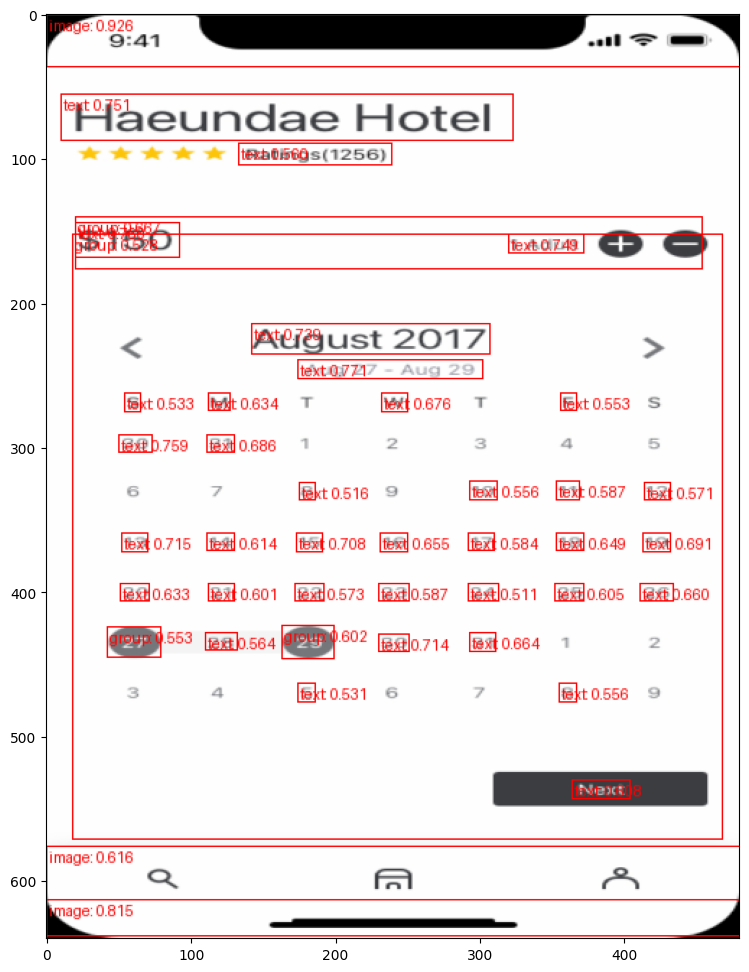

In [5]:
# Tamanho do dataset de teste.
len_test_data = len(test_dataset)

# Sortear amostra do dataset de teste.
idx = torch.randint(len_test_data, (1,))

# Modelo em modo de avaliação
model.eval()
with torch.no_grad():
    x = test_dataset[idx]["image"][0]
    # convert RGBA -> RGB and move to device
    x = x[:3, ...].to(device)
    predictions = model([x, ])
    pred = predictions[0]

# Mapeamento inverso das classes (respeitando o deslocamento de +1)
inverse_label_map = {1: "rectangle", 2: "text", 3: "group", 4: "image", 0: "background"}

# Filtro de confiança: manter apenas as caixas delimitadoras cuja confiança é maior que 0.5
keep = pred["scores"] > 0.5
pred_boxes = pred["boxes"][keep].long()
pred_labels = [f"{inverse_label_map.get(int(label.cpu()), 'bg')}: {score:.3f}" for label, score in zip(pred["labels"][keep], pred["scores"][keep])]

image = x
image = (255.0 * (image - image.min()) / (image.max() - image.min())).to(torch.uint8)
image = image[:3, ...]

if len(pred_boxes) > 0:
    output_image = torchvision.utils.draw_bounding_boxes(image, pred_boxes, pred_labels, colors="red")
else:
    output_image = image

plt.figure(figsize=(12, 12))
plt.imshow(output_image.permute(1, 2, 0).cpu())

## Próximos Passos e Referências

Nas próximas práticas vamos continuar trabalhando com problemas reais que envolvem Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://docs.pytorch.org/vision/master/models/faster_rcnn.html
- https://huggingface.co/datasets/mrtoy/mobile-ui-design
- https://huggingface.co/datasets
- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opcional)

- [x] **Teste de Robustez com Team Sonic (Out-of-Distribution)** — resolvida logo abaixo (leve: só inferência no modelo já treinado).
- [x] **Efeito do learning rate** — resolvida na seção opcional/pesada no fim (re-treina rápido com 2 LRs).
- [ ] **Sugestão livre:** treine por mais épocas e veja se as detecções melhoram.

Vamos submeter uma imagem do Sonic (`img/sonic.jpg`) ao modelo Faster R-CNN treinado para verificar se ele detecta erroneamente algum componente visual de interface no corpo do personagem.

Imagem do Sonic encontrada em: /content/sonic.jpg
O modelo detectou 4 possíveis elementos de UI no Sonic!


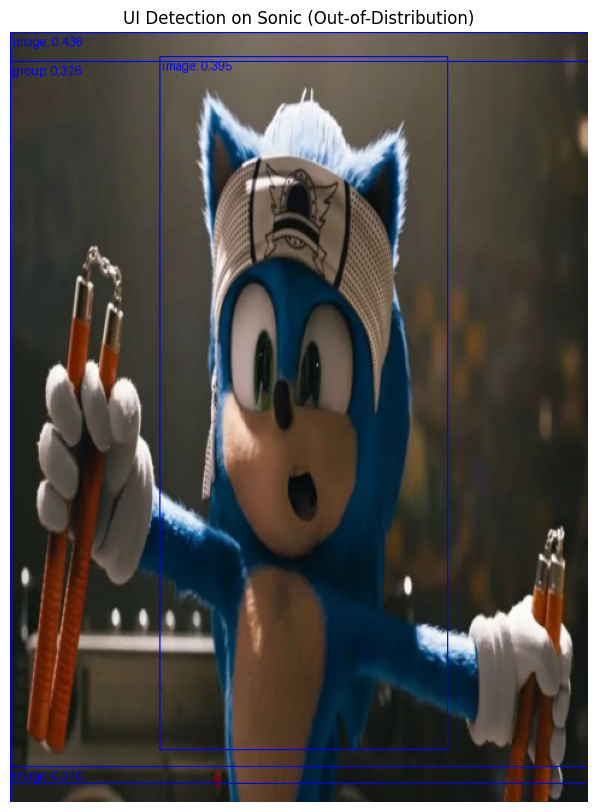

In [6]:
import os

# Caminho para a imagem do Sonic
sonic_path = "/content/sonic.jpg"
if not os.path.exists(sonic_path):
    sonic_path = "sonic.jpg"
if not os.path.exists(sonic_path):
    sonic_path = "../../img/sonic.jpg"
if not os.path.exists(sonic_path):
    sonic_path = "img/sonic.jpg"

if not os.path.exists(sonic_path):
    print("ERRO: Imagem do Sonic não encontrada!")
else:
    print(f"Imagem do Sonic encontrada em: {sonic_path}")

    # Carregar imagem do Sonic, converter para RGB e aplicar transformações
    from PIL import Image
    sonic_img = Image.open(sonic_path).convert("RGB")
    transform_func = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Resize((640, 480)),
    ])
    sonic_tensor = transform_func(sonic_img).to(device)

    model.eval()
    with torch.no_grad():
        sonic_preds = model([sonic_tensor])[0]

    # Usaremos um limiar de confiança mais baixo (0.3) para esta exploração lúdica
    sonic_keep = sonic_preds["scores"] > 0.3
    sonic_boxes = sonic_preds["boxes"][sonic_keep].long()
    sonic_labels = [f"{inverse_label_map.get(int(lbl.cpu()), 'bg')}: {score:.3f}"
                    for lbl, score in zip(sonic_preds["labels"][sonic_keep], sonic_preds["scores"][sonic_keep])]

    # Formatar imagem para draw_bounding_boxes
    sonic_disp = (255.0 * (sonic_tensor - sonic_tensor.min()) / (sonic_tensor.max() - sonic_tensor.min())).to(torch.uint8)

    if len(sonic_boxes) > 0:
        sonic_out = torchvision.utils.draw_bounding_boxes(sonic_disp, sonic_boxes, sonic_labels, colors="blue")
        print(f"O modelo detectou {len(sonic_boxes)} possíveis elementos de UI no Sonic!")
    else:
        sonic_out = sonic_disp
        print("Nenhum elemento de UI foi detectado no Sonic com confiança > 0.3.")

    plt.figure(figsize=(10, 10))
    plt.imshow(sonic_out.permute(1, 2, 0).cpu())
    plt.axis("off")
    plt.title("UI Detection on Sonic (Out-of-Distribution)")
    plt.show()

---
# ⏸️ Ponto de parada

## Atividade (opcional/pesada): Efeito do Learning Rate

Treinamos rapidamente (apenas alguns batches) com dois *learning rates* diferentes e comparamos a
**perda média**. Assim dá pra sentir como o LR afeta a estabilidade do treino, sem pagar um treino
completo.

In [7]:
import itertools

def treino_curto(lr, n_batches=50):
    """Treina um Faster R-CNN do zero por poucos batches e retorna a perda média."""
    m = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    m.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
        m.roi_heads.box_predictor.cls_score.in_features, num_classes)
    m.to(device)
    m.train()
    opt = torch.optim.SGD(m.parameters(), lr=lr, momentum=0.9, weight_decay=0.0001)
    losses = []
    for images, targets in itertools.islice(train_loader, n_batches):
        images = [im.to(device) for im in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss = sum(l for l in m(images, targets).values())
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return sum(losses) / len(losses)

print("Comparando learning rates (50 batches cada)...")
loss_baixo = treino_curto(0.001)
loss_alto = treino_curto(0.005)
print(f"  lr=0.001  ->  perda média: {loss_baixo:.4f}")
print(f"  lr=0.005  ->  perda média: {loss_alto:.4f}")
print()
print("Intuição: LR muito alto pode tornar o treino instável (perda alta/oscilando);")
print("LR muito baixo aprende devagar. O 'ponto certo' depende do problema.")

Comparando learning rates (50 batches cada)...
  lr=0.001  ->  perda média: 2.6120
  lr=0.005  ->  perda média: 2.2296

Intuição: LR muito alto pode tornar o treino instável (perda alta/oscilando);
LR muito baixo aprende devagar. O 'ponto certo' depende do problema.
